# Interactive visualization of donald trump vs hillary clinton tweet based sentiment analysis 

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer 
import plotly.offline as py#visualization
py.init_notebook_mode(connected=True)#visualization
import plotly.graph_objs as go#visualization
import plotly.tools as tls#visualization
import plotly.figure_factory as ff#visualization
import warnings
warnings.filterwarnings("ignore",category=DeprecationWarning)
import matplotlib.pyplot as plt#visualization
%matplotlib inline

# Read the data

In [2]:
df = pd.read_csv("trump.hillary tweets.csv")
df = df[[ 'handle', 'text', 'is_retweet', 'original_author', 
                 'time', 'lang', 'retweet_count', 'favorite_count']]

In [3]:
df.head()

,handle,text,is_retweet,original_author,time,lang,retweet_count,favorite_count
0,HillaryClinton,The question in this election: Who can put the...,False,NaN,2016-09-28T00:22:34,en,218,651
1,HillaryClinton,"Last night, Donald Trump said not paying taxes...",True,timkaine,2016-09-27T23:45:00,en,2445,5308
2,HillaryClinton,Couldn't be more proud of @HillaryClinton. Her...,True,POTUS,2016-09-27T23:26:40,en,7834,27234
3,HillaryClinton,"If we stand together, there's nothing we can't...",False,NaN,2016-09-27T23:08:41,en,916,2542
4,HillaryClinton,Both candidates were asked about how they'd co...,False,NaN,2016-09-27T22:30:27,en,859,2882


# lets check the data types

In [4]:
df.dtypes

handle             object
text               object
is_retweet           bool
original_author    object
time               object
lang               object
retweet_count       int64
favorite_count      int64
dtype: object

# lets check the null value

In [5]:
df.isnull().sum() / df.shape[0]

handle             0.000000
text               0.000000
is_retweet         0.000000
original_author    0.887958
time               0.000000
lang               0.000000
retweet_count      0.000000
favorite_count     0.000000
dtype: float64

# languages in tweets

In [6]:
df['lang'].value_counts()

en     6248
es      105
und      82
da        3
fr        2
tl        2
et        1
fi        1
Name: lang, dtype: int64

In [7]:
def language(df) :
    if df["lang"] == "en" :
        return "English"
    elif df["lang"] == "es" :
        return "Spanish"
    else :
        return "Other"

df["lang"] = df.apply(lambda tweets:language(tweets),axis = 1)


# datetime convert
from datetime import datetime
date_format = "%Y-%m-%dT%H:%M:%S" 
df["time"]   = pd.to_datetime(df["time"],format = date_format)
df["hour"]   = pd.DatetimeIndex(df["time"]).hour
df["month"]  = pd.DatetimeIndex(df["time"]).month
df["day"]    = pd.DatetimeIndex(df["time"]).day
df["month_f"]  = df["month"].map({1:"JAN",2:"FEB",3:"MAR",
                                        4:"APR",5:"MAY",6:"JUN",
                                        7:"JUL",8:"AUG",9:"SEP"})

In [8]:
#trump tweets without retweets
tweets_trump = (df[(df["handle"] == "realDonaldTrump") &
                         (df["is_retweet"] == False)].reset_index()
                  .drop(columns = ["index"],axis = 1))

In [9]:
tweets_trump.head()

,handle,text,is_retweet,original_author,time,lang,retweet_count,favorite_count,hour,month,day,month_f
0,realDonaldTrump,Join me for a 3pm rally - tomorrow at the Mid-...,False,NaN,2016-09-27 22:13:24,English,2181,6172,22,9,27,SEP
1,realDonaldTrump,"Once again, we will have a government of, by a...",False,NaN,2016-09-27 21:08:22,English,4132,11239,21,9,27,SEP
2,realDonaldTrump,Hillary Clinton's Campaign Continues To Make F...,False,NaN,2016-09-27 20:14:33,English,3833,9840,20,9,27,SEP
3,realDonaldTrump,"'CNBC, Time magazine online polls say Donald T...",False,NaN,2016-09-27 20:06:25,English,4236,10948,20,9,27,SEP
4,realDonaldTrump,Great afternoon in Little Havana with Hispanic...,False,NaN,2016-09-27 19:59:04,English,4878,14110,19,9,27,SEP


In [10]:
#hillary tweets without retweets
tweets_hillary = (df[(df["handle"] == "HillaryClinton") &
                            (df["is_retweet"] == False)].reset_index()
                              .drop(columns = ["index"],axis = 1))
tweets_hillary.head()

,handle,text,is_retweet,original_author,time,lang,retweet_count,favorite_count,hour,month,day,month_f
0,HillaryClinton,The question in this election: Who can put the...,False,NaN,2016-09-28 00:22:34,English,218,651,0,9,28,SEP
1,HillaryClinton,"If we stand together, there's nothing we can't...",False,NaN,2016-09-27 23:08:41,English,916,2542,23,9,27,SEP
2,HillaryClinton,Both candidates were asked about how they'd co...,False,NaN,2016-09-27 22:30:27,English,859,2882,22,9,27,SEP
3,HillaryClinton,This election is too important to sit out. Go ...,False,NaN,2016-09-27 21:35:28,English,1303,2849,21,9,27,SEP
4,HillaryClinton,When Donald Trump goes low...register to vote:...,False,NaN,2016-09-27 21:25:31,English,1833,4954,21,9,27,SEP


In [11]:
data=pd.concat([df.handle, df.text], axis=1)

In [12]:
data.dropna(axis=0, inplace=True)  

In [13]:
data.handle.value_counts() 

HillaryClinton     3226
realDonaldTrump    3218
Name: handle, dtype: int64

<AxesSubplot:xlabel='handle', ylabel='count'>

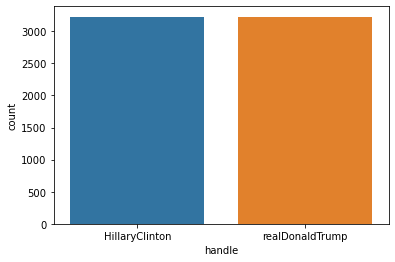

In [14]:
#Total number of tweets by both of the twitter handles
sns.countplot(x='handle', data = df)

<AxesSubplot:title={'center':'Monthly Tweet Counts'}, xlabel='month'>

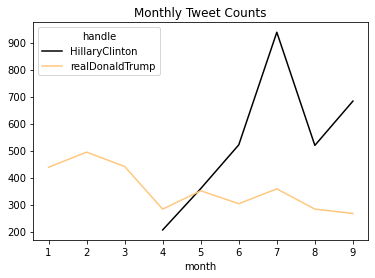

In [15]:
#Number of tweets by the months
monthly_tweets = df.groupby(['month', 'handle']).size().unstack()
monthly_tweets.plot(title='Monthly Tweet Counts', colormap='copper')

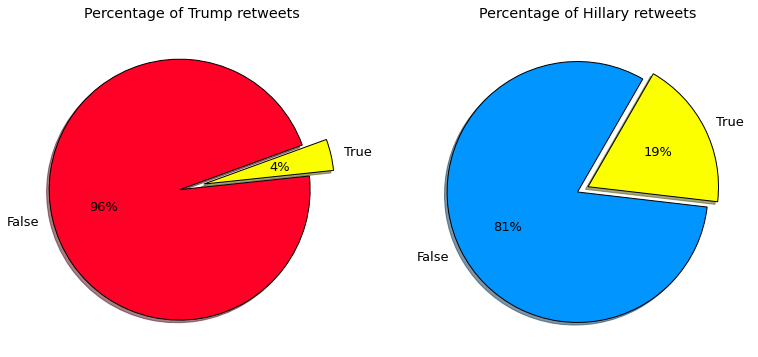

In [16]:
plt.style.use('ggplot')

plt.figure(figsize = (13,6))
plt.subplot(121)
df[df["handle"] ==
       "realDonaldTrump"]["is_retweet"].value_counts().plot.pie(autopct = "%1.0f%%",
                                                                wedgeprops = {"linewidth" : 1,
                                                                              "edgecolor" : "k"},
                                                                shadow = True,fontsize = 13,
                                                                explode = [.1,0.09],
                                                                startangle = 20,
                                                                colors = ["#ff0026","#fbff00"]
                                                               )
plt.ylabel("")
plt.title("Percentage of Trump retweets")


plt.subplot(122)
df[df["handle"] ==
       "HillaryClinton"]["is_retweet"].value_counts().plot.pie(autopct = "%1.0f%%",
                                                                wedgeprops = {"linewidth" : 1,
                                                                              "edgecolor" : "k"},
                                                                shadow = True,fontsize = 13,
                                                                explode = [.09,0],
                                                                startangle = 60,
                                                                colors = ["#0095ff","#fbff00"]
                                                               )
plt.ylabel("")
plt.title("Percentage of Hillary retweets")
plt.show()

# Donald trump tweet sentimental analysis

In [17]:
analyzer = SentimentIntensityAnalyzer()

def calculate_sentiment_scores(sentence):
    sntmnt = analyzer.polarity_scores(sentence)['compound']
    return(sntmnt)

In [18]:
import nltk 
import re
nltk.download("stopwords")          
nltk.download("punkt")

from nltk.corpus import stopwords
eng_snt_score =  []

for comment in tweets_trump.text.to_list():
    comment = re.sub("[^a-zA-Z]"," ", comment)
    comment= comment.lower()
    comment= nltk.word_tokenize(comment)
    comment = [ word for word in comment if not word in set(stopwords.words("english"))]
    lemma = nltk.WordNetLemmatizer()
    comment = [lemma.lemmatize(word) for word in comment]
    comment = " ".join(comment)
    snts_score = calculate_sentiment_scores(comment)
    eng_snt_score.append(snts_score)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\sande\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\sande\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [19]:
tweets_trump['sentiment_score'] = np.array(eng_snt_score)
tweets_trump.head()

,handle,text,is_retweet,original_author,time,lang,retweet_count,favorite_count,hour,month,day,month_f,sentiment_score
0,realDonaldTrump,Join me for a 3pm rally - tomorrow at the Mid-...,False,NaN,2016-09-27 22:13:24,English,2181,6172,22,9,27,SEP,0.2960
1,realDonaldTrump,"Once again, we will have a government of, by a...",False,NaN,2016-09-27 21:08:22,English,4132,11239,21,9,27,SEP,0.2960
2,realDonaldTrump,Hillary Clinton's Campaign Continues To Make F...,False,NaN,2016-09-27 20:14:33,English,3833,9840,20,9,27,SEP,0.0000
3,realDonaldTrump,"'CNBC, Time magazine online polls say Donald T...",False,NaN,2016-09-27 20:06:25,English,4236,10948,20,9,27,SEP,0.0000
4,realDonaldTrump,Great afternoon in Little Havana with Hispanic...,False,NaN,2016-09-27 19:59:04,English,4878,14110,19,9,27,SEP,0.8519


In [20]:
i = 0

vader_sentiment = [ ]

while(i<len(tweets_trump)):
    if ((tweets_trump.iloc[i]['sentiment_score'] >= 0.05)):
        vader_sentiment.append('positive')
        i = i+1
    elif ((tweets_trump.iloc[i]['sentiment_score'] > -0.05) & (tweets_trump.iloc[i]['sentiment_score'] < 0.05)):
        vader_sentiment.append('neutral')
        i = i+1
    elif ((tweets_trump.iloc[i]['sentiment_score'] <= -0.05)):
        vader_sentiment.append('negative')
        i = i+1

In [21]:
tweets_trump['vader_sentiment_labels'] = vader_sentiment 

In [22]:
tweets_trump.vader_sentiment_labels.value_counts()

positive    1755
negative     849
neutral      489
Name: vader_sentiment_labels, dtype: int64

In [23]:
tweets_trump.head()

,handle,text,is_retweet,original_author,time,lang,retweet_count,favorite_count,hour,month,day,month_f,sentiment_score,vader_sentiment_labels
0,realDonaldTrump,Join me for a 3pm rally - tomorrow at the Mid-...,False,NaN,2016-09-27 22:13:24,English,2181,6172,22,9,27,SEP,0.2960,positive
1,realDonaldTrump,"Once again, we will have a government of, by a...",False,NaN,2016-09-27 21:08:22,English,4132,11239,21,9,27,SEP,0.2960,positive
2,realDonaldTrump,Hillary Clinton's Campaign Continues To Make F...,False,NaN,2016-09-27 20:14:33,English,3833,9840,20,9,27,SEP,0.0000,neutral
3,realDonaldTrump,"'CNBC, Time magazine online polls say Donald T...",False,NaN,2016-09-27 20:06:25,English,4236,10948,20,9,27,SEP,0.0000,neutral
4,realDonaldTrump,Great afternoon in Little Havana with Hispanic...,False,NaN,2016-09-27 19:59:04,English,4878,14110,19,9,27,SEP,0.8519,positive


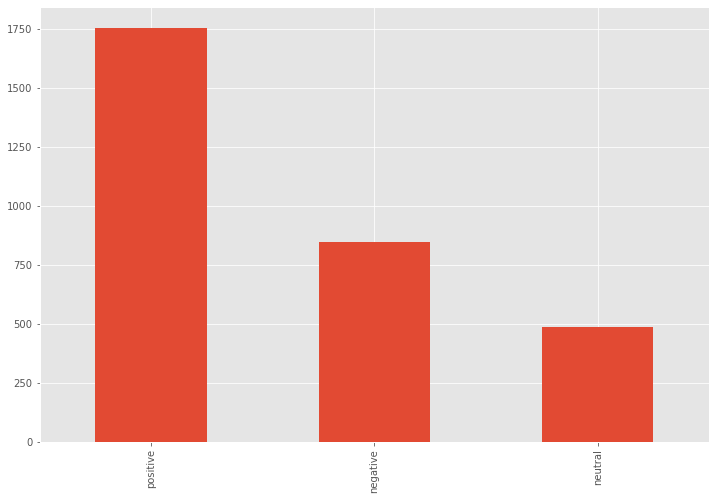

In [24]:
tweets_trump['vader_sentiment_labels'].value_counts().plot(kind='bar',figsize=(12,8));

# Hilory clinton tweet sentimental analysis

In [25]:
eng_snt_score =  []

for comment in tweets_hillary.text.to_list():
    comment = re.sub("[^a-zA-Z]"," ", comment)
    comment = comment.lower()
    comment = nltk.word_tokenize(comment)
    comment = [ word for word in comment if not word in set(stopwords.words("english"))]
    lemma = nltk.WordNetLemmatizer()
    comment = [lemma.lemmatize(word) for word in comment]
    comment = " ".join(comment)
    snts_score = calculate_sentiment_scores(comment)
    eng_snt_score.append(snts_score)

In [26]:
tweets_hillary['sentiment_score'] = np.array(eng_snt_score)
tweets_hillary.head()


,handle,text,is_retweet,original_author,time,lang,retweet_count,favorite_count,hour,month,day,month_f,sentiment_score
0,HillaryClinton,The question in this election: Who can put the...,False,NaN,2016-09-28 00:22:34,English,218,651,0,9,28,SEP,0.4404
1,HillaryClinton,"If we stand together, there's nothing we can't...",False,NaN,2016-09-27 23:08:41,English,916,2542,23,9,27,SEP,-0.4717
2,HillaryClinton,Both candidates were asked about how they'd co...,False,NaN,2016-09-27 22:30:27,English,859,2882,22,9,27,SEP,-0.6597
3,HillaryClinton,This election is too important to sit out. Go ...,False,NaN,2016-09-27 21:35:28,English,1303,2849,21,9,27,SEP,0.4767
4,HillaryClinton,When Donald Trump goes low...register to vote:...,False,NaN,2016-09-27 21:25:31,English,1833,4954,21,9,27,SEP,-0.2732


In [27]:
i = 0

vader_sentiment = [ ]

while(i<len(tweets_hillary)):
    if ((tweets_hillary.iloc[i]['sentiment_score'] >= 0.05)):
        vader_sentiment.append('positive')
        i = i+1
    elif ((tweets_hillary.iloc[i]['sentiment_score'] > -0.05) & (tweets_hillary.iloc[i]['sentiment_score'] < 0.05)):
        vader_sentiment.append('neutral')
        i = i+1
    elif ((tweets_hillary.iloc[i]['sentiment_score'] <= -0.05)):
        vader_sentiment.append('negative')
        i = i+1

In [28]:
tweets_hillary['vader_sentiment_labels'] = vader_sentiment

In [29]:
tweets_hillary.vader_sentiment_labels.value_counts()

positive    1290
negative     736
neutral      603
Name: vader_sentiment_labels, dtype: int64

In [30]:
tweets_hillary.head()

,handle,text,is_retweet,original_author,time,lang,retweet_count,favorite_count,hour,month,day,month_f,sentiment_score,vader_sentiment_labels
0,HillaryClinton,The question in this election: Who can put the...,False,NaN,2016-09-28 00:22:34,English,218,651,0,9,28,SEP,0.4404,positive
1,HillaryClinton,"If we stand together, there's nothing we can't...",False,NaN,2016-09-27 23:08:41,English,916,2542,23,9,27,SEP,-0.4717,negative
2,HillaryClinton,Both candidates were asked about how they'd co...,False,NaN,2016-09-27 22:30:27,English,859,2882,22,9,27,SEP,-0.6597,negative
3,HillaryClinton,This election is too important to sit out. Go ...,False,NaN,2016-09-27 21:35:28,English,1303,2849,21,9,27,SEP,0.4767,positive
4,HillaryClinton,When Donald Trump goes low...register to vote:...,False,NaN,2016-09-27 21:25:31,English,1833,4954,21,9,27,SEP,-0.2732,negative


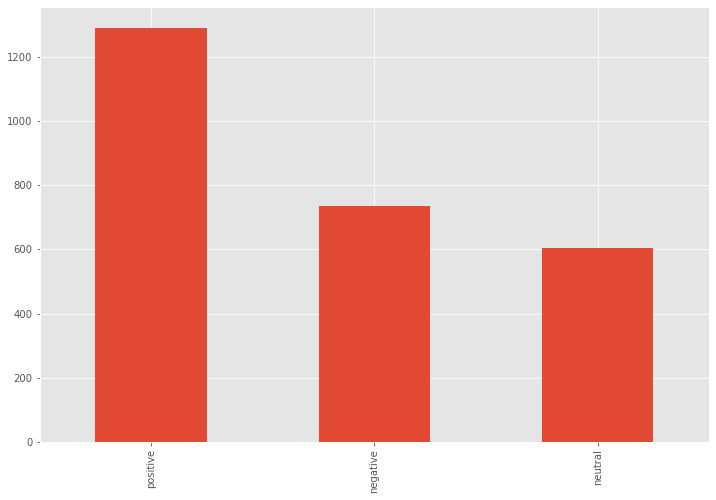

In [31]:
tweets_hillary['vader_sentiment_labels'].value_counts().plot(kind='bar',figsize=(12,8));

# word cloud

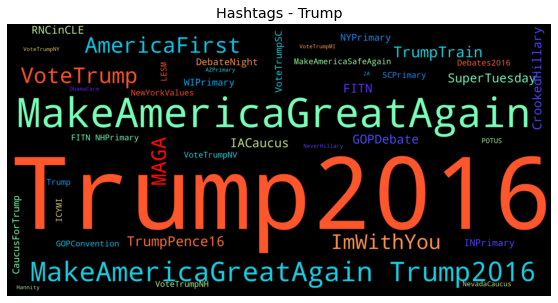

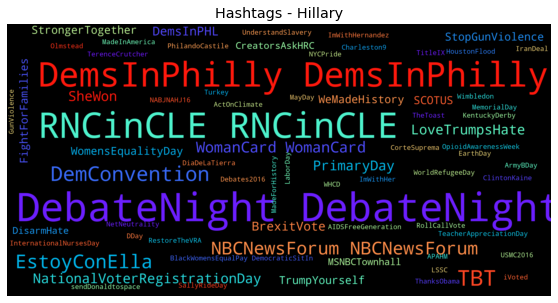

In [48]:
from wordcloud import WordCloud

hsh_wrds_t = tweets_trump["text"].str.extractall(r'(\#\w+)')[0]
hsh_wrds_h = tweets_hillary["text"].str.extractall(r'(\#\w+)')[0]

def build_word_cloud(words,back_color,palette,title) :
    word_cloud = WordCloud(scale = 7,max_words = 1000,
                           max_font_size = 100,background_color = back_color,
                           random_state = 0,colormap = palette
                          ).generate(" ".join(words))
    plt.figure(figsize = (11,5))
    plt.imshow(word_cloud,interpolation = "bilinear")
    plt.axis("off")
    plt.title(title)
    plt.show()

build_word_cloud(hsh_wrds_t,"black","rainbow","Hashtags - Trump")
build_word_cloud(hsh_wrds_h,"black","rainbow","Hashtags - Hillary")

In [33]:
#TFIDF vectorizer.
import sklearn
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(min_df=2, max_df=0.5, ngram_range=(1,2))
text_count_matrix = tfidf.fit_transform(tweets_trump.text)

In [34]:
text_count_matrix 

<3093x8487 sparse matrix of type '<class 'numpy.float64'>'
	with 72622 stored elements in Compressed Sparse Row format>

In [35]:
#split the dataset  
#train dataset
train_reviews=text_count_matrix[:2475]
train_sentiments=tweets_trump.sentiment_score[:2475]
#test dataset
test_reviews=tweets_trump.text[2475:]
test_sentiments=tweets_trump.sentiment_score[2475:]
print(train_reviews.shape,train_sentiments.shape)
print(test_reviews.shape,test_sentiments.shape)

(2475, 8487) (2475,)
(618,) (618,)


In [36]:
#tweets_trump.loc[int(tweets_trump['sentiment_score']>0)] = "positive"
tweets_trump.loc[tweets_trump['sentiment_score']<0] = "negative"

In [37]:
text_count_matrix2 = tfidf.fit_transform(tweets_trump.text)
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(text_count_matrix2, tweets_trump.sentiment_score, test_size=0.20, random_state=2)
Y_train = (Y_train.replace({'positive': 1, 'negative': 0})).values
Y_test = (Y_test.replace({'positive': 1, 'negative': 0})).values

In [38]:
Y_test

array([0.5574, 0.765 , 0.7906, 0.    , 0.8779, 0.    , 0.    , 0.    ,
       0.9348, 0.    , 0.    , 0.8807, 0.    , 0.571 , 0.    , 0.    ,
       0.296 , 0.296 , 0.7717, 0.    , 0.    , 0.8316, 0.    , 0.3612,
       0.4939, 0.    , 0.4215, 0.    , 0.    , 0.6249, 0.8885, 0.765 ,
       0.3612, 0.    , 0.    , 0.    , 0.6249, 0.7096, 0.4404, 0.    ,
       0.    , 0.8316, 0.    , 0.    , 0.    , 0.6249, 0.3612, 0.8481,
       0.    , 0.    , 0.    , 0.    , 0.    , 0.6249, 0.9382, 0.3612,
       0.5423, 0.    , 0.539 , 0.    , 0.    , 0.3612, 0.4939, 0.    ,
       0.802 , 0.296 , 0.    , 0.    , 0.6249, 0.6908, 0.    , 0.7351,
       0.7717, 0.    , 0.    , 0.    , 0.4019, 0.228 , 0.    , 0.    ,
       0.91  , 0.3612, 0.    , 0.2911, 0.    , 0.7096, 0.    , 0.    ,
       0.6249, 0.296 , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    ,
       0.5635, 0.7717, 0.6249, 0.4588, 0.    , 0.3612, 0.3612, 0.296 ,
       0.4019, 0.9056, 0.    , 0.5859, 0.    , 0.    , 0.6908, 0.    ,
      

In [39]:
#Using Linear-SVC with preprocessed data 
from sklearn.svm import SVR

In [40]:
from sklearn.metrics import mean_squared_error
LSVC = SVR()
LSVC.fit(X_train, Y_train)
from sklearn import metrics
from sklearn.metrics import classification_report, confusion_matrix
accuracy_score = LSVC.predict(X_test)

print(mean_squared_error(accuracy_score,Y_test))
LSVC_pred=mean_squared_error(accuracy_score,Y_test)


0.042350035017268604


In [41]:
from sklearn import linear_model


linearregr = linear_model.LinearRegression()
linearregr.fit(X_train, Y_train)
linpredict = linearregr.predict(X_test)
print(mean_squared_error(linpredict,Y_test))
lin_pred=mean_squared_error(linpredict,Y_test)


0.036087488868269214


In [42]:
from sklearn.neighbors import KNeighborsRegressor
knn = KNeighborsRegressor(n_neighbors=6)
knn.fit(X_train, Y_train)
knnpredict = knn.predict(X_test)
print(mean_squared_error(knnpredict,Y_test))
knn_pred=mean_squared_error(knnpredict,Y_test)

0.058065951350744924


In [43]:
from sklearn.linear_model import LassoCV

LR = LassoCV(cv=5)
LR.fit(X_train, Y_train)
lrpredict = LR.predict(X_test)
print(mean_squared_error(lrpredict,Y_test))
lr_pred=mean_squared_error(lrpredict,Y_test)

0.030372749896905225


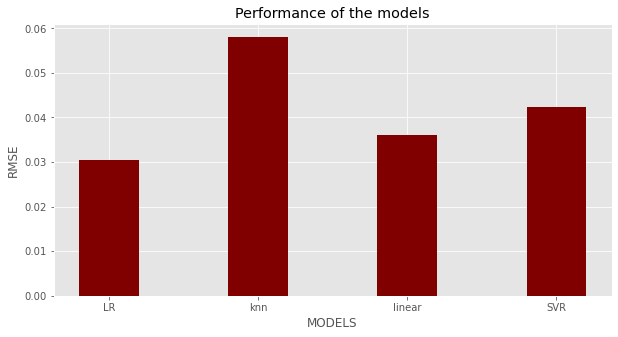

In [44]:
import numpy as np
import matplotlib.pyplot as plt
 
  
# creating the dataset
data = {'LR':lr_pred, 'knn':knn_pred, 'linear':lin_pred,
        'SVR':LSVC_pred}
courses = list(data.keys())
values = list(data.values())
  
fig = plt.figure(figsize = (10, 5))
 
# creating the bar plot
plt.bar(courses, values, color ='maroon',
        width = 0.4)
 
plt.xlabel("MODELS")
plt.ylabel("RMSE")
plt.title("Performance of the models")
plt.show()